In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
import pandas as pd

In [7]:
k_values = range(2, 16)

In [8]:
DATASET_PATH = "scaled_emotion_dataset.parquet"
OUTPUT_DIR = "optimal_k_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
df = pd.read_parquet(DATASET_PATH)

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print(f"Shape : {df.shape}")

df.head()

DATASET LOADED
Shape : (61079, 30)


,comment_id,comment_text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,UgzctbxqZgshZ8gon294AaABAg,This shit was retarded I wasn't even stressed ...,-0.468964,0.054959,4.238163,7.972156,-0.562920,-0.473405,-0.220090,-0.266303,...,-0.303048,-0.307088,-0.396475,-0.200539,-0.337736,-0.396863,-0.198793,-0.450829,-0.055406,-0.541746
1,Ugw-Y7stczH-a4Wv3T94AaABAg,Its terrible I wish it would just stop,-0.451183,-0.106158,0.226987,0.246696,-0.543016,-0.446506,-0.190537,-0.233795,...,-0.270368,-0.046303,0.520207,-0.155581,-0.384399,-0.402691,-0.209150,-0.286621,-0.054151,-0.554262
2,UgzWhdA-bcUlXL8n9_V4AaABAg,"Smell something gross it'll help calm you, hel...",-0.450968,-0.140866,-0.066077,0.468519,0.564387,1.479282,-0.234139,-0.261821,...,-0.299947,-0.300440,0.700209,-0.100990,-0.365538,0.038257,-0.222914,-0.527694,-0.173185,-0.145300
3,Ugz6ySN9lU9tN4rJutx4AaABAg,Just came here for a bit of reassurance after ...,-0.459893,-0.146448,-0.050691,0.360819,-0.371426,-0.419434,-0.225197,-0.258718,...,-0.299857,0.371526,-0.358743,-0.170014,-0.354973,-0.257851,-0.262838,-0.460840,-0.154983,-0.429491
4,UgwSP4dqy6_mJmFJ6Wd4AaABAg,Ohh so you're telling me i have been having pa...,-0.476383,-0.124842,-0.183468,-0.290332,-0.529544,-0.455667,0.930189,2.376182,...,-0.297100,1.171948,-0.397261,-0.224187,0.076538,-0.311327,-0.219073,-0.497806,0.462019,-0.397170


In [10]:
X = df.copy()

print(f"Feature Matrix Shape: {X.shape}")

Feature Matrix Shape: (61079, 30)


In [11]:
X = df.drop(
    columns=[
        "comment_id",
        "comment_text",
        "mental_health_label"
    ],
    errors="ignore"
)

print(f"Feature Matrix Shape: {X.shape}")

Feature Matrix Shape: (61079, 28)


In [13]:
inertia = []
silhouette = []
davies = []
calinski = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)

    silhouette.append(
        silhouette_score(X, labels, sample_size=10000, random_state=42)
    )

    davies.append(
        davies_bouldin_score(X, labels)
    )

    calinski.append(
        calinski_harabasz_score(X, labels)
    )

print("Finished!")

Finished!


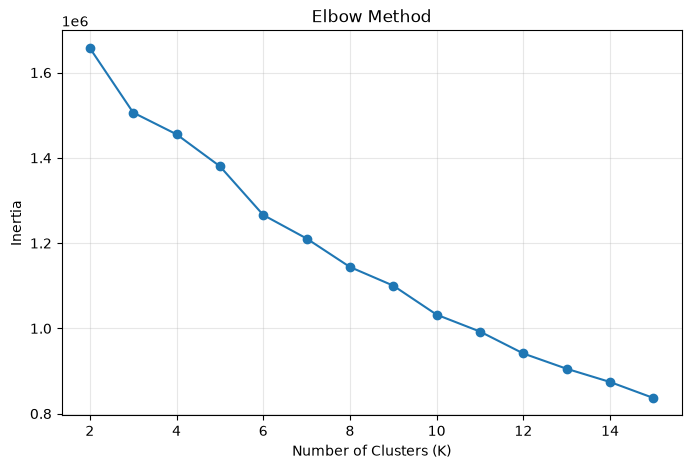

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(alpha=0.3)

plt.savefig(
    os.path.join(OUTPUT_DIR, "elbow_method.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

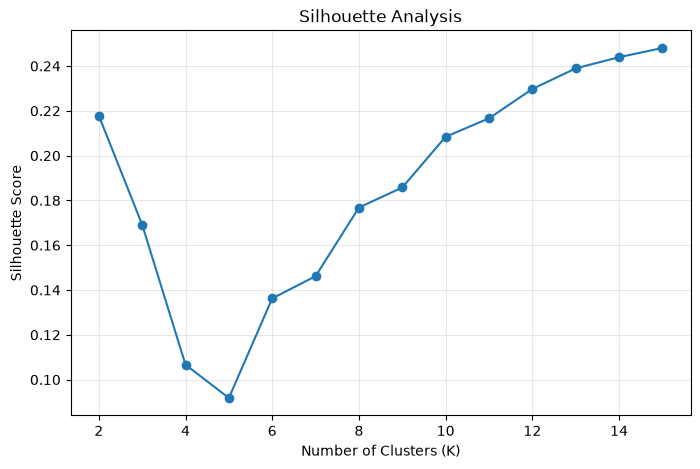

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(alpha=0.3)

plt.savefig(
    os.path.join(OUTPUT_DIR, "silhouette_score.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

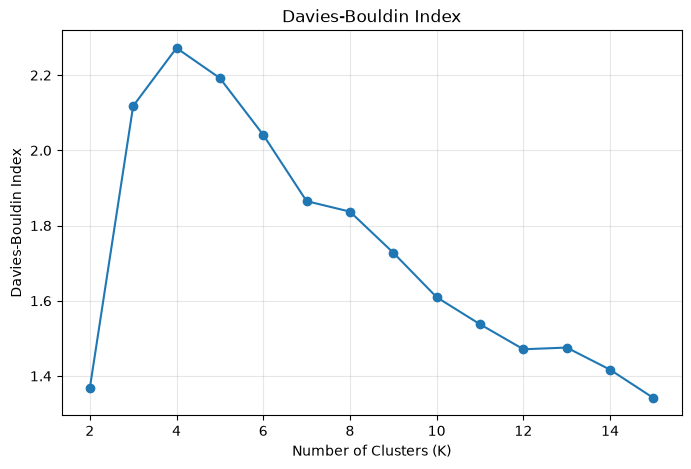

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    davies,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")

plt.title("Davies-Bouldin Index")

plt.grid(alpha=0.3)

plt.savefig(
    os.path.join(OUTPUT_DIR, "davies_bouldin.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

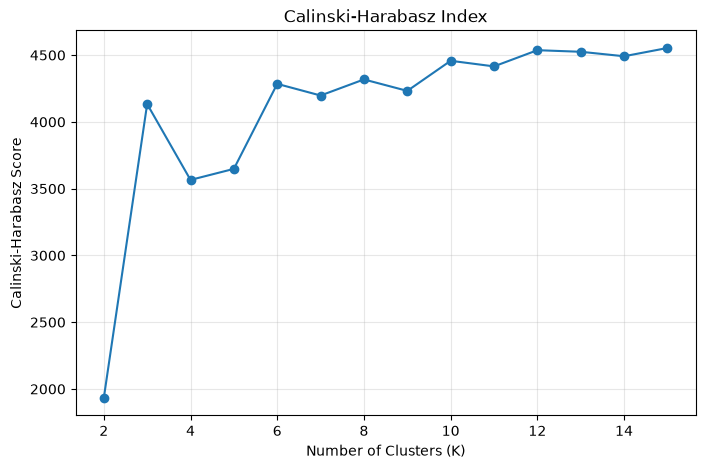

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    calinski,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")

plt.title("Calinski-Harabasz Index")

plt.grid(alpha=0.3)

plt.savefig(
    os.path.join(OUTPUT_DIR, "calinski_harabasz.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette": silhouette,
    "Davies_Bouldin": davies,
    "Calinski_Harabasz": calinski
})

results

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,1.657763e+06,0.217881,1.367318,1932.388570
1,3,1.506317e+06,0.169192,2.117928,4133.620221
2,4,1.455331e+06,0.106662,2.272247,3565.487465
3,5,1.380387e+06,0.091793,2.192159,3648.205707
4,6,1.266085e+06,0.136263,2.041322,4284.733410
5,7,1.210870e+06,0.146169,1.865029,4197.513759
6,8,1.144016e+06,0.176817,1.837110,4317.886458
7,9,1.100240e+06,0.185772,1.727818,4232.148195
8,10,1.032155e+06,0.208416,1.609555,4457.585552
9,11,9.925402e+05,0.216644,1.537630,4415.618944
